In [4]:
# Day 6: Color-Based Object Detection (HSV Masking + Contour Filtering)
# Covers: BGR→HSV conversion, cv2.inRange() color masking,
#  and isolating a target object
#  from background noise using contour area + circularity filtering.

In [5]:
!pip install -q ultralytics

[ 37 255 145]


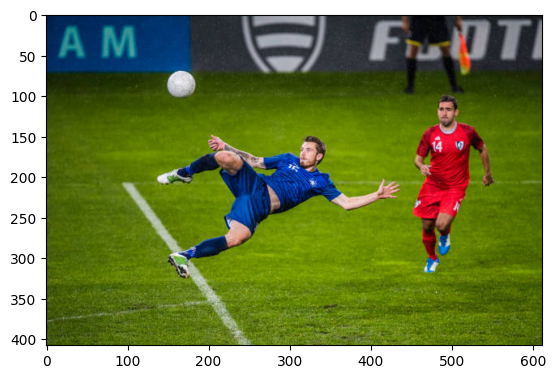

In [6]:
#Task 1 : Convert BGR → HSV

import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/football image.jpg")

hsv = cv2.cvtColor(img,cv2.COLOR_BGR2HSV)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
print(hsv[150, 300])

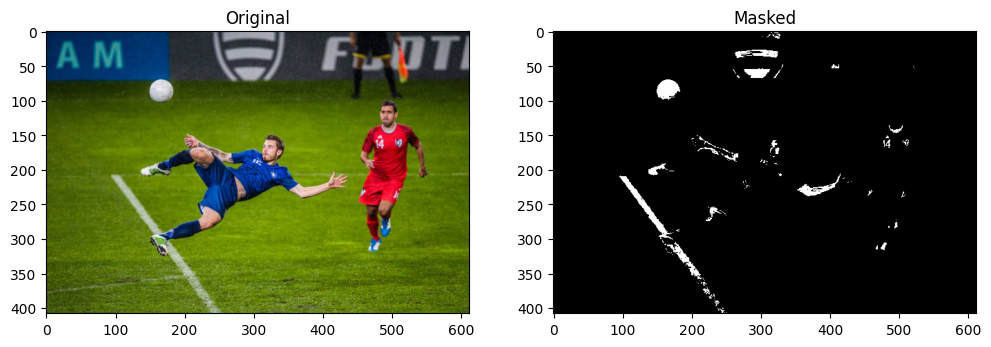

In [16]:
# Task 2: define a color range for your target object (the ball)
#  in HSV and use cv2.inRange() to create a mask.
# You'll need:

# Two numpy arrays: a lower bound and upper bound of H, S, V values for the color you're isolating
# cv2.inRange() — takes the HSV image + lower + upper bounds, returns a binary mask

import numpy as np
lower = np.array([0, 0, 180])
upper = np.array([179, 60, 255])
mask = cv2.inRange(hsv, lower, upper)
fig,axes = plt.subplots(1,2,figsize =(12,5))
#showing Original
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")

#showing Masked image
axes[1].imshow(mask,cmap="gray")
axes[1].set_title("Masked")
plt.show()

0.7375003298188918 (166.40672302246094, 86.41896057128906) 16.768768310546875


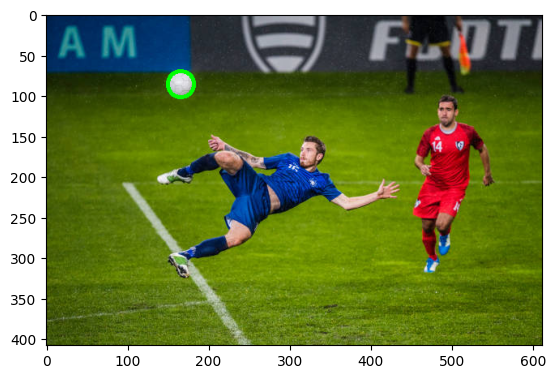

In [14]:
# Task 3 — Filtered noisy contours by area and circularity to isolate the ball,
#  tracked the best candidate, and drew the result on the image — confirmed visually correct

# Task 3: Isolate the ball using contour filtering

contour_exter, hierarchy = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

best_ratio = 0
best_contour = None
best_center = None
best_radius = None

for contour in contour_exter:
    area = cv2.contourArea(contour)
    if area > 100:
        center, radius = cv2.minEnclosingCircle(contour)
        circle_area = np.pi * radius**2
        ratio = area / circle_area
        if ratio > best_ratio:
            best_ratio = ratio
            best_contour = contour
            best_center = center
            best_radius = radius

print(best_ratio, best_center, best_radius)

# Draw the result
img_copy = img.copy()
center_int = (int(best_center[0]), int(best_center[1]))
radius_int = int(best_radius)
cv2.circle(img_copy, center_int, radius_int, (0, 255, 0), 4)

plt.imshow(cv2.cvtColor(img_copy, cv2.COLOR_BGR2RGB))
plt.show()